In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [69]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

In [70]:
import pickle

In [71]:
df = pd.read_csv("preprocessed_demand_forecasting_data.csv")

In [72]:
features = [
    "Price",
    "Discount",
    "Inventory Level",
    "Promotion",
    "Competitor Pricing",
    "Category"
]

In [73]:
features

['Price',
 'Discount',
 'Inventory Level',
 'Promotion',
 'Competitor Pricing',
 'Category']

In [74]:
target = "Demand"

In [75]:
X = df[features].copy()

In [76]:
X

,Price,Discount,Inventory Level,Promotion,Competitor Pricing,Category
0,72.72,5,195,0,85.73,Electronics
1,80.16,15,117,1,92.02,Clothing
2,62.94,10,247,1,60.08,Clothing
3,87.63,10,139,0,85.19,Electronics
4,54.41,0,152,0,51.63,Groceries
...,...,...,...,...,...,...
75995,29.80,5,233,0,32.23,Toys
75996,42.92,5,137,0,40.73,Toys
75997,17.81,10,197,0,19.41,Clothing
75998,151.72,0,125,0,143.71,Furniture


In [77]:
y = df[target]

In [78]:
y

0        115
1        229
2        157
3         52
4         59
        ... 
75995     64
75996    137
75997     68
75998     84
75999     73
Name: Demand, Length: 76000, dtype: int64

In [79]:
label_encoders = {}

categorical_cols = X.select_dtypes(include="object").columns

In [80]:
categorical_cols

Index(['Category'], dtype='object')

In [81]:
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

In [82]:
label_encoders

{'Category': LabelEncoder()}

In [83]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size= 0.2)

In [84]:
xgb = XGBRegressor(objective="reg:squarederror", n_jobs = -1)

In [85]:
param_dict = {
    "n_estimators": [200, 300, 500],
    "max_depth": [3,4,6,8],
    "learning_rate": [0.01,0.05, 0.1],
    "subsample": [0.7, 0.8,1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "min_child_weight": [1,3,5]
}

In [86]:
random_search= RandomizedSearchCV(
    estimator= xgb,
    param_distributions= param_dict,
    n_iter= 25,
    scoring="neg_mean_absolute_error",
    cv=3,
    verbose= 1,
    n_jobs= -1
)

In [87]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=-1,
                                          num_parallel_tree=None, ...),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 4, 6, 8],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [200, 300, 500],
                                        'subsample': [0.7, 0.8, 1.0]},
                   scoring='neg_mean_absolute_error', verbose=1)

In [88]:
random_search.best_params_

{'subsample': 0.7,
 'n_estimators': 200,
 'min_child_weight': 3,
 'max_depth': 8,
 'learning_rate': 0.05,
 'colsample_bytree': 0.8}

In [89]:
best_model = random_search.best_estimator_

In [90]:
y_pred = best_model.predict(X_test)

In [94]:
#mean_squared_error(y_test, y_pred, squared=False)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(rmse)

35.636564392203795


In [97]:
feature_importance = pd.Series(
    best_model.feature_importances_,
    index= X.columns
).sort_values(ascending=False)

<Axes: title={'center': 'Feature Importances'}>

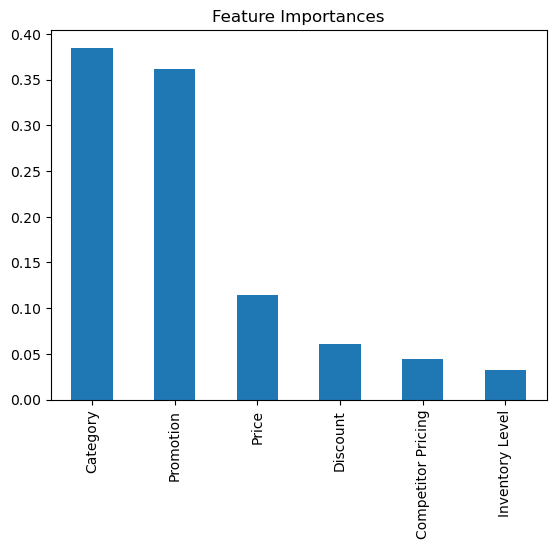

In [100]:
feature_importance.plot(kind="bar", title="Feature Importances")

In [102]:
with open ("label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders,f)

In [103]:
with open ("xgboost_demand_model.pkl","wb") as f:
    pickle.dump(best_model,f)